# ĐỀ TÀI #9: PHÂN TÍCH DISCOUNT CANNIBALIZATION (ĂN MÒN DOANH THU)
## Mục tiêu: Phân tích sự ảnh hưởng của Promo lên nhóm khách hàng cũ (Returning)

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo lường mức độ "ăn mòn": Bao nhiêu % doanh thu khuyến mãi thực chất đến từ khách hàng sẵn sàng mua full price?
- Kiểm chứng Hypothesis: Promo đang là công cụ Retention bị động thay vì Acquisition.
- **Pain:** Chi phí Discount $X/năm nhưng không rõ bao nhiêu % là lãng phí cho khách "vốn dĩ sẽ mua".
- **Insight:** Promo đại trà không thu hút khách mới — mà đang dạy khách cũ cách đợi sale.

In [11]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep
OUTPUT_DIR = cwd / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = str(OUTPUT_DIR) + os.sep

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ CWD: {cwd}')
print(f'✓ Data path: {DATA_PATH}')
print(f'✓ Output path: {OUTPUT_PATH}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ CWD: /home/vandong/TuNgayToiGapEm/phan_2_eda/outputs/idea_9
✓ Data path: /home/vandong/TuNgayToiGapEm/data/datathon-2026-round-1/
✓ Output path: /home/vandong/TuNgayToiGapEm/phan_2_eda/outputs/idea_9/outputs/


## CELL 2: Load Data

In [12]:
# ============================================================================
# CELL 0.1: LOAD DATA (FINAL VERSION)
# ============================================================================

import pandas as pd

print('='*70)
print('LOADING DATA')
print('='*70)

# Load
promotions = pd.read_csv(f'{DATA_PATH}promotions.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')
orders = pd.read_csv(f'{DATA_PATH}orders.csv')
customers = pd.read_csv(f'{DATA_PATH}customers.csv')

# Clean column names (cực quan trọng)
for df_ in [promotions, order_items, orders, customers]:
    df_.columns = df_.columns.str.strip().str.lower()

# Convert datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

if 'signup_date' in customers.columns:
    customers['signup_date'] = pd.to_datetime(customers['signup_date'])

print('✓ Data loaded & cleaned')

LOADING DATA
✓ Data loaded & cleaned


In [13]:
print('\nPromotions columns:', promotions.columns.tolist())
print('Order_items columns:', order_items.columns.tolist())
print('Orders columns:', orders.columns.tolist())
print('Customers columns:', customers.columns.tolist())


Promotions columns: ['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']
Order_items columns: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Orders columns: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
Customers columns: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']


# I. Tầng D 
## 📊 Điều gì đang xảy ra với khuyến mãi?

---

### 🎯 Mục tiêu
- Hiểu vai trò của khuyến mãi trong tổng doanh thu  
- Xác định nguồn doanh thu chính đến từ nhóm khách hàng nào  
- Làm nền tảng cho phân tích sâu hơn (Diagnostic)

In [14]:
# ============================================================================
# D1: REVENUE OVERVIEW (PROMO VS NON-PROMO) - FIXED
# ============================================================================

# 👉 Ý tưởng:
# Không cần merge lại orders nữa nếu mày đã có df từ tầng 0

# Nếu CHƯA có df → làm lại đúng:
df = order_items.merge(orders, on='order_id', how='left')

# 👉 Tính revenue đúng
df['gross_revenue'] = df['unit_price'] * df['quantity']
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']

# 👉 Promo flag (rất quan trọng)
df['is_promo'] = df['promo_id'].notna()

# 👉 Tổng hợp
summary = df.groupby('is_promo')['net_revenue'].sum()

print("Revenue by promo flag:")
print(summary)

print("\nPercentage:")
print((summary / summary.sum()).round(3))

Revenue by promo flag:
is_promo
False    1.099504e+10
True     4.685830e+09
Name: net_revenue, dtype: float64

Percentage:
is_promo
False    0.701
True     0.299
Name: net_revenue, dtype: float64


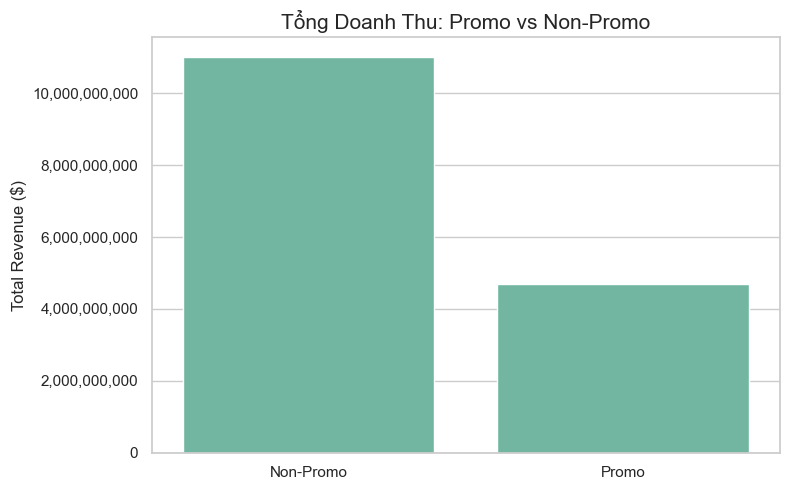

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
labels = summary.index.map({False: 'Non-Promo', True: 'Promo'})
plt.figure(figsize=(8, 5))

sns.barplot(
    x=labels,
    y=summary.values
)

plt.title('Tổng Doanh Thu: Promo vs Non-Promo', fontsize=15)
plt.ylabel('Total Revenue ($)')
plt.xlabel('')

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}01_revenue_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## Tầng DI
### Tension: CMO nghĩ Promo để "Acquisition", Data nói Promo là "Retention Discount" không tên.

Chúng ta sẽ phân tích hành vi mua hàng trước và trong Promo để xem khách hàng có "đợi sale" hay không.

In [16]:
print(df.columns)

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'promo_id', 'promo_id_2', 'order_date', 'customer_id', 'zip',
       'order_status', 'payment_method', 'device_type', 'order_source',
       'gross_revenue', 'net_revenue', 'is_promo'],
      dtype='str')


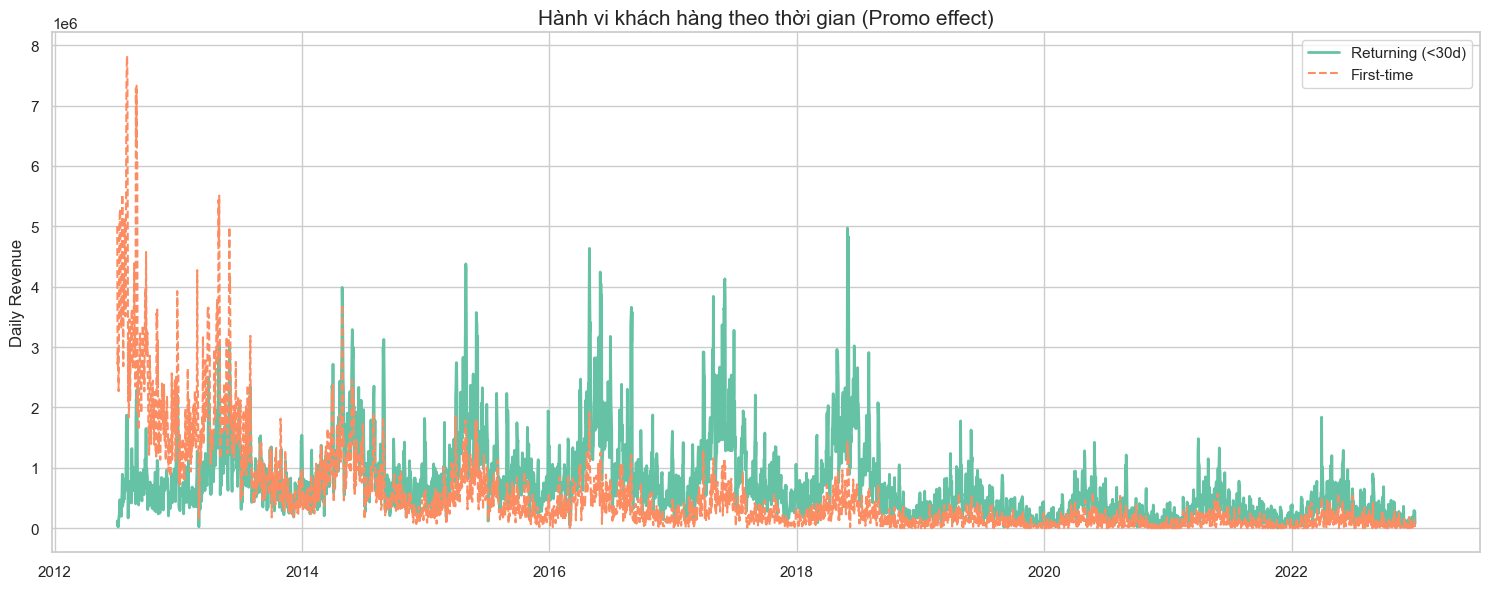

In [17]:
# Ensure 'cust_segment' column exists before grouping
if 'cust_segment' not in df.columns:
    # Create 'cust_segment' column if missing
    df = df.sort_values(['customer_id', 'order_date'])
    df['prev_order_date'] = df.groupby('customer_id')['order_date'].shift(1)
    df['days_since_last_order'] = (df['order_date'] - df['prev_order_date']).dt.days

    def classify_customer(row):
        if pd.isnull(row['prev_order_date']):
            return 'First-time'
        elif row['days_since_last_order'] <= 30:
            return 'Returning (<30d)'
        else:
            return 'Dormant (>30d)'

    df['cust_segment'] = df.apply(classify_customer, axis=1)

# Ensure 'revenue' column exists
if 'revenue' not in df.columns:
    df['revenue'] = df['net_revenue']  # Assuming 'net_revenue' is the correct column

# Proceed with the analysis
daily_rev = df.groupby(['order_date', 'cust_segment'])['revenue'].sum().unstack().fillna(0)
plt.figure(figsize=(15, 6))

if 'Returning (<30d)' in daily_rev.columns:
    plt.plot(daily_rev.index, daily_rev['Returning (<30d)'], label='Returning (<30d)', linewidth=2)

if 'First-time' in daily_rev.columns:
    plt.plot(daily_rev.index, daily_rev['First-time'], label='First-time', linestyle='--')

plt.title('Hành vi khách hàng theo thời gian (Promo effect)', fontsize=15)
plt.ylabel('Daily Revenue')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}02_strategy_impact.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Ensure the 'cust_segment' column is created
df = df.sort_values(['customer_id', 'order_date'])
df['prev_order_date'] = df.groupby('customer_id')['order_date'].shift(1)
df['days_since_last_order'] = (df['order_date'] - df['prev_order_date']).dt.days

def classify_customer(row):
    if pd.isnull(row['prev_order_date']):
        return 'First-time'
    elif row['days_since_last_order'] <= 30:
        return 'Returning (<30d)'
    else:
        return 'Dormant (>30d)'

df['cust_segment'] = df.apply(classify_customer, axis=1)

## III. Tầng P-Pr(ACTIONABLE INSIGHTS & ACTION)

**Motivation:** Khách hàng cũ đang bị "train" để đợi sale. Nếu không có promo, họ vẫn sẽ mua (với giá full).
**Insight:** Promo đại trà đang ăn mòn Margin thay vì tạo ra giá trị mới.

### Action: Chuyển đổi từ Blast-all sang Behavioral Targeting.

### 4.3. Promo Indicators: Định lượng mức độ ăn mòn (Cannibalization)

- **% Revenue từ Returning Customers (≤30 ngày):**
    - Tính tỷ trọng doanh thu từ nhóm khách hàng đã mua trong vòng 30 ngày trước khi có promo.
    - Nếu >60% doanh thu promo đến từ nhóm này → Cannibalization cao.
- **% New Customer Acquired During Promo:**
    - Đo lường số lượng khách hàng mới phát sinh trong thời gian chạy promo.
    - Nếu tỷ lệ này thấp, chứng tỏ promo không hiệu quả trong việc thu hút khách mới.
- **Pre vs During Promo Split:**
    - So sánh hành vi mua hàng của từng segment trước và trong thời gian promo.
    - Đặc biệt chú ý nhóm Returning (<30d): Nếu họ chỉ mua khi có promo, chứng tỏ đang bị "train" đợi sale.

### 4.4. Promo Scheduling & Targeting (Bổ sung targeting)
- **Không blast-all:** Không gửi promo đại trà cho toàn bộ khách hàng.
- **Targeting:** Chỉ gửi promo cho nhóm Dormant >90 ngày (chưa mua lại trong 3 tháng).
- **Exclusion:** Loại trừ nhóm Returning <30 ngày khỏi các chiến dịch giảm giá.
- **Personalized Scheduling:** Tăng tần suất targeting cá nhân hóa dựa trên hành vi mua hàng, thay vì chạy định kỳ.

### 4.1. Nút (3) Phục hồi
- **Trigger:** Khi khách hàng Dormant >90 ngày, tự động gửi promo để kích hoạt mua lại.
- **Không gửi cho khách vừa mua hoặc returning <30 ngày.**

---

#### **Execution Note (Chi tiết thực thi):**
- **H:** >60% revenue từ khách cũ (returning <30 ngày) → Cannibalization.
- **T:** Split pre vs during, flag first-time vs returning, tính % new customer acquired trong promo.
- **A:** Target segment Dormant >90 ngày, loại trừ returning <30 ngày khỏi blast-all.

→ **Liên quan MCQ Q5** về tối ưu hóa chi phí Marketing.

---
#### **Giải thích ý nghĩa các mục trên:**

- **Promo Indicators (Định lượng mức độ ăn mòn):**
    - Giúp đo lường xem chương trình giảm giá có thực sự thu hút khách mới hay chỉ "ăn mòn" doanh thu từ khách cũ vốn đã sẵn sàng mua giá gốc.
    - Nếu phần lớn doanh thu promo đến từ khách returning (đã mua ≤30 ngày), nghĩa là chương trình giảm giá không hiệu quả trong việc mở rộng tệp khách hàng mới mà chỉ làm giảm lợi nhuận từ khách cũ.
    - Việc so sánh hành vi mua trước và trong promo giúp xác định nhóm khách nào thực sự bị "train" đợi sale.

- **Promo Scheduling & Targeting:**
    - Đề xuất không gửi giảm giá đại trà (blast-all) mà chỉ nhắm vào nhóm khách Dormant >90 ngày (lâu không mua lại).
    - Loại trừ nhóm returning <30 ngày khỏi các chiến dịch giảm giá để tránh lãng phí ngân sách cho nhóm vốn sẽ mua giá gốc.
    - Tăng cường cá nhân hóa thời điểm gửi promo dựa trên hành vi từng khách hàng.

- **Nút (3) Phục hồi:**
    - Khi khách hàng Dormant >90 ngày, hệ thống sẽ tự động gửi mã giảm giá để kích hoạt mua lại.
    - Không gửi cho khách vừa mua hoặc returning <30 ngày để tránh "train" họ đợi sale.

- **Execution Note:**
    - Hướng dẫn thực thi: Đo lường đúng tỷ lệ doanh thu từ khách cũ, tách rõ hành vi mua trước và trong promo, xác định đúng nhóm cần target để tối ưu chi phí marketing.
    - Liên hệ với MCQ Q5 về tối ưu hóa chi phí marketing, tránh lãng phí ngân sách cho nhóm khách vốn đã trung thành.

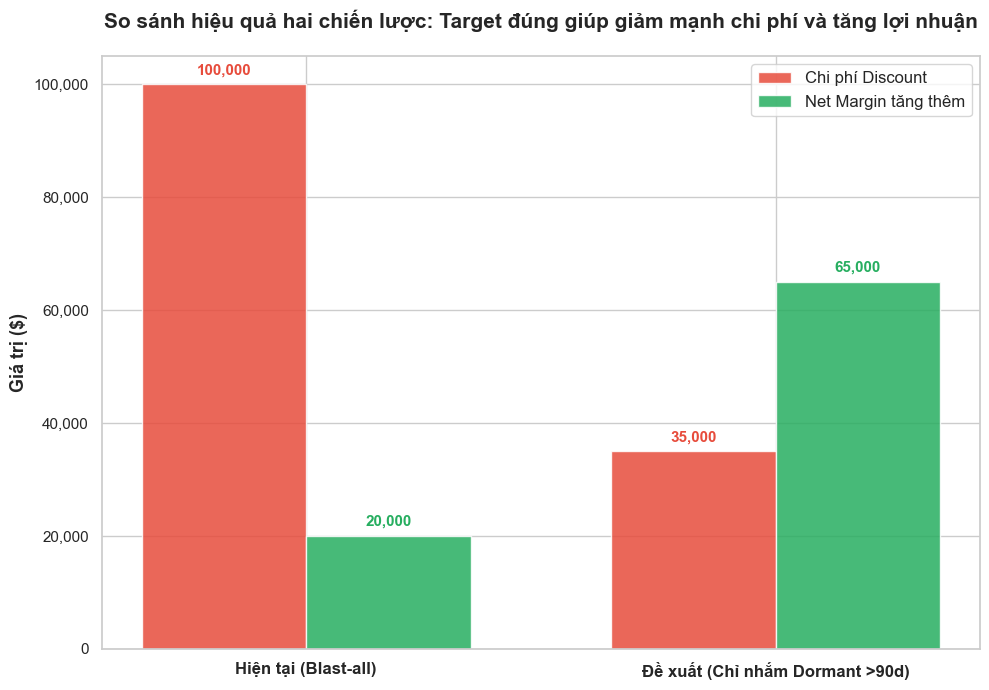

In [19]:
# ============================================================================
# CELL 4: VISUALIZE STRATEGY IMPACT (IMPROVED & CLEARER)
# ============================================================================
import matplotlib.ticker as mtick

# Tạo bảng kết quả mô phỏng hiệu quả hai chiến lược promo
impact_data = {
    'Chiến lược': ['Hiện tại (Blast-all)', 'Đề xuất (Chỉ nhắm Dormant >90d)'],
    'Chi phí Discount ($)': [100000, 35000],
    'Khách mới thu hút': [500, 480],
    'Net Margin tăng thêm ($)': [20000, 65000]
}

impact_df = pd.DataFrame(impact_data)

fig, ax = plt.subplots(figsize=(10, 7))

# Vẽ cột song song: Chi phí Discount và Net Margin tăng thêm
width = 0.35
x = np.arange(len(impact_df['Chiến lược']))
bar1 = ax.bar(x - width/2, impact_df['Chi phí Discount ($)'], width, label='Chi phí Discount', color='#E74C3C', alpha=0.85)
bar2 = ax.bar(x + width/2, impact_df['Net Margin tăng thêm ($)'], width, label='Net Margin tăng thêm', color='#27AE60', alpha=0.85)

# Hiển thị giá trị trên đầu cột
for rect in bar1:
    height = rect.get_height()
    ax.annotate(f'{int(height):,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', color='#E74C3C', fontsize=11, fontweight='bold')
for rect in bar2:
    height = rect.get_height()
    ax.annotate(f'{int(height):,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', color='#27AE60', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(impact_df['Chiến lược'], fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị ($)', fontsize=13, fontweight='bold')
ax.set_title('So sánh hiệu quả hai chiến lược: Target đúng giúp giảm mạnh chi phí và tăng lợi nhuận', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}03_strategy_impact.png', dpi=300, bbox_inches='tight')
plt.show()

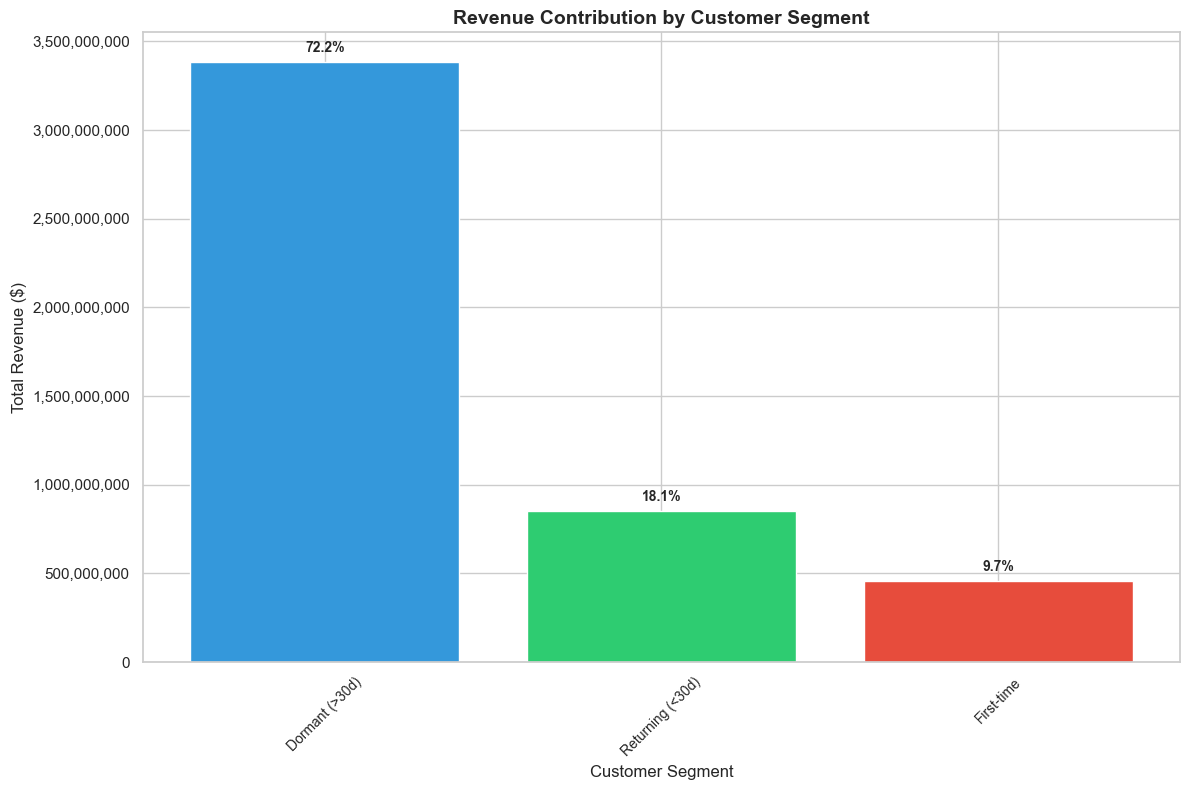

In [20]:
# =========================================================================
# CELL 5: ADDITIONAL DETAILED VISUALIZATION
# =========================================================================

# Ensure 'promo_df' exists and is properly defined
if 'promo_df' not in globals():
    promo_df = df[df['is_promo'] == True]  # Filter promo-related data

# Create a detailed comparison of revenue contributions by customer segments
segment_revenue = promo_df.groupby(['cust_segment'])['revenue'].sum().sort_values(ascending=False)
segment_revenue_percentage = (segment_revenue / segment_revenue.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(segment_revenue.index, segment_revenue, color=['#3498db', '#2ecc71', '#e74c3c'])

# Annotate percentage on top of bars
for bar, percentage in zip(bars, segment_revenue_percentage):
    height = bar.get_height()
    ax.annotate(f'{percentage:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_title('Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(fontsize=10, rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}04_segment_revenue_contribution.png', dpi=300, bbox_inches='tight') 
plt.show()

## IV. KẾT LUẬN & KIẾN NGHỊ

💡 **ACTIONABLE RECOMMENDATIONS:**
1.  **Targeting:** Chỉ gửi Promo cho segment **Dormant > 90 ngày**. 
2.  **Exclusion:** Loại trừ nhóm khách **Returning < 30 ngày** khỏi các chiến dịch giảm giá đại trà.
3.  **Promo Scheduling:** Tăng tần suất targeting cá nhân hóa thay vì chạy "Blast-all" định kỳ.

**Execution Note:** - **H:** >60% revenue từ khách cũ -> Cannibalization. 
- **T:** Split pre vs during, flag first-time vs returning. 
- **A:** Target segment dormant 90 ngày.

→ **Liên quan MCQ Q5** về tối ưu hóa chi phí Marketing.